# softmax 回归 · 简洁实现（PyTorch）

> 📌 **出处**：李沐《动手学深度学习 V2》第 3 章「softmax 回归的简洁实现」
> 🎯 **目标**：用 `torch.nn` 的高级 API 重写 softmax 回归，重点搞清楚一个容易踩的坑——**`nn.CrossEntropyLoss` 到底吃「概率」还是「分数」。**

## 简洁实现三件套

| 手写（从零） | 框架 API（简洁） |
| --- | --- |
| 手写 `softmax` + 展平 + 线性层 | `nn.Sequential(nn.Flatten(), nn.Linear(784, 10))` |
| 手写 `cross_entropy` | `nn.CrossEntropyLoss` |
| 手写 `sgd` | `optim.SGD` |

> 🔑 **关键坑**：`nn.CrossEntropyLoss` 内部**自己会做 softmax**，所以模型的最后一层**不要**再写 softmax，直接输出 10 个**原始分数（logits）**即可。


In [1]:
# ==================== 环境准备 ====================
import torch
import numpy as np
import matplotlib.pyplot as plt
!pip install torchvision -q
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

蓝 = '#2b7bba'; 橙 = '#e69f00'; 灰 = '#999999'; 红 = '#d62728'; 绿 = '#2ca02c'; 紫 = '#9467bd'
np.random.seed(0); torch.manual_seed(0)

print("✓ 环境就绪：torch", torch.__version__)


✓ 环境就绪：torch 2.14.0+cpu


## 1. 加载数据（和从零实现完全一样）

沿用 Fashion-MNIST。首次运行自动下载到 `../data`。


In [2]:
# ---- 加载 Fashion-MNIST ----
from torchvision import datasets, transforms
from torch.utils import data

def load_data_fashion_mnist(batch_size, root='../data'):
    trans = transforms.ToTensor()
    mnist_train = datasets.FashionMNIST(root=root, train=True,  transform=trans, download=True)
    mnist_test  = datasets.FashionMNIST(root=root, train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True),
            data.DataLoader(mnist_test,  batch_size, shuffle=False))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)
print("训练 batch 数：", len(train_iter), "| 测试 batch 数：", len(test_iter))


训练 batch 数： 235 | 测试 batch 数： 40


## 2. 定义模型：Flatten + Linear，一行搞定

- `nn.Flatten()`：把每张 28×28 图**自动展平**成 784 维（省掉手写 `reshape`）；
- `nn.Linear(784, 10)`：线性层，输出 10 个**分数**。

> 💡 注意：模型里**没有** softmax！因为 `CrossEntropyLoss` 会在算损失时自己 softmax。模型在训练时输出分数，预测时再手动 `argmax` 取类别。


In [3]:
# ---- 定义模型 + 初始化 ----
from torch import nn

net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)   # 权重：N(0, 0.01)

net.apply(init_weights)
print("模型结构：", net)


模型结构： Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


## 3. 损失 + 优化器 + 训练

`CrossEntropyLoss` 一步完成「softmax + 交叉熵」。训练循环仍是四步：**清零梯度 → 反向 → 更新**。


In [4]:
# ---- 损失 + 优化器 + 训练 ----
loss = nn.CrossEntropyLoss()                          # softmax + 交叉熵，一步到位
trainer = torch.optim.SGD(net.parameters(), lr=0.1)   # 学习率 0.1（softmax 回归的标准取值）

num_epochs = 10
for epoch in range(num_epochs):
    # 训练
    for X, y in train_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    # 训练集指标
    with torch.no_grad():
        总损失, 总命中, 总数 = 0.0, 0.0, 0
        for X, y in train_iter:
            y_hat = net(X)
            总损失 += float(loss(y_hat, y)) * y.numel()   # mean 损失 × 样本数 = 该 batch 损失总和
            总命中 += float((y_hat.argmax(axis=1) == y).sum())
            总数 += y.numel()
        print(f"epoch {epoch+1:2d}: 训练损失 {总损失/总数:.4f}, 准确率 {总命中/总数:.4f}")


epoch  1: 训练损失 0.6094, 准确率 0.7993
epoch  2: 训练损失 0.5372, 准确率 0.8232
epoch  3: 训练损失 0.5145, 准确率 0.8275
epoch  4: 训练损失 0.4965, 准确率 0.8331
epoch  5: 训练损失 0.4946, 准确率 0.8311
epoch  6: 训练损失 0.4718, 准确率 0.8414
epoch  7: 训练损失 0.4728, 准确率 0.8362
epoch  8: 训练损失 0.4553, 准确率 0.8446
epoch  9: 训练损失 0.4457, 准确率 0.8489
epoch 10: 训练损失 0.4495, 准确率 0.8451


## 4. 测试集评估 + 可视化预测

对比从零实现和简洁实现：**准确率基本一致（约 82~85%）**，但代码量少了很多。这再次印证——简洁实现底层做的就是从零实现那套计算。


测试集准确率：0.8295


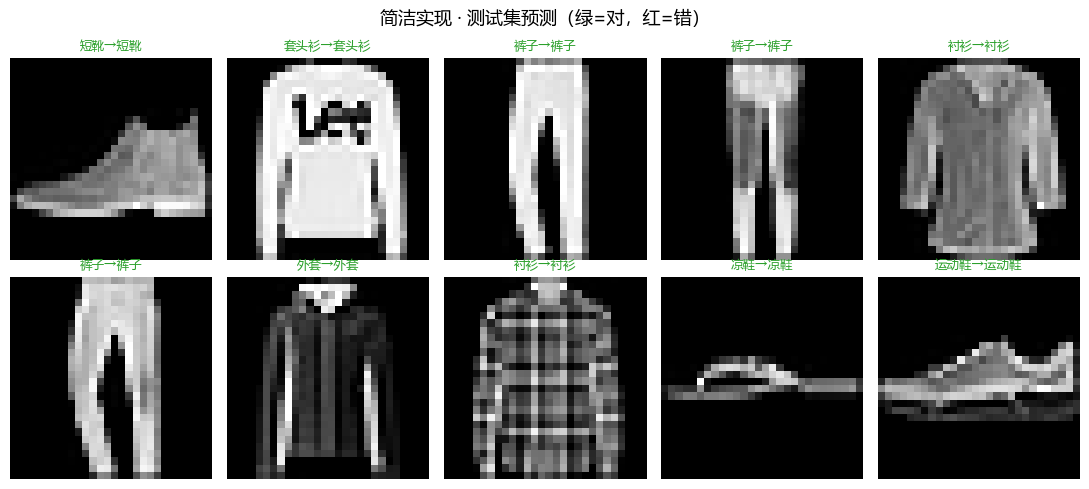

In [5]:
# ---- 测试集准确率 + 可视化 ----
with torch.no_grad():
    总命中, 总数 = 0.0, 0
    for X, y in test_iter:
        总命中 += float((net(X).argmax(axis=1) == y).sum())
        总数 += y.numel()
print(f"测试集准确率：{总命中/总数:.4f}")

类别名 = ['T恤', '裤子', '套头衫', '连衣裙', '外套', '凉鞋', '衬衫', '运动鞋', '包', '短靴']
X, y = next(iter(test_iter))
with torch.no_grad():
    预测 = net(X).argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].squeeze().numpy(), cmap='gray')
    color = 绿 if 预测[i] == y[i] else 红
    ax.set_title(f"{类别名[y[i].item()]}→{类别名[预测[i].item()]}", color=color, fontsize=9)
    ax.axis('off')
fig.suptitle('简洁实现 · 测试集预测（绿=对，红=错）', fontsize=13)
plt.tight_layout(); plt.show()
